<div align="center">
     <h1>Trabajo Semanal N°2</h1>
     <h2>Trombetta,Nicolas</h2>
</div>

Queremos hallar la función transferencia pasa bajos mediante aproximación de máxima planicidad, por caso, Butteworth, de orden 6.
Para ello plamteamos:
\begin{equation}
|T(s)|^2=T(s) T^*(s)=\frac{1}{1+S^{12}}
\end{equation}
Entonces queremos hallar los polos:
\begin{equation}
S^{12}=-1
\end{equation}

\begin{equation}
(|S|e^{j arg(S)})^{12}=1e^{j(2k+1)\pi}
\end{equation}

Finalmente se obtiene que los polos se encuentran en:
\begin{equation}
|S|=1
\end{equation}
\begin{equation}
arg(s)=\frac{(2k+1)\pi}{12};k=0,1,2,..,11;
\end{equation}
Para hallar la funcion transferencia descartamos los polos que no nos interesan, es decir, los que estan del lado derecho del eje $jw$
\begin{equation}
T(S)=\frac{1}{\prod_{k=3}^{8} (S-1e^{\frac{j(2k+1)\pi}{12}})}
\end{equation}

Agrupando nos queda:
\begin{equation}
T(S)=\frac{1}{(S^2-S2cos(\frac{7}{12}\pi)+1)}\frac{1}{(S^2-S2cos(\frac{9}{12}\pi)+1)}\frac{1}{(S^2-S2cos(\frac{11}{12}\pi)+1)}
\end{equation}

### Implementacion de la red
Primero calculas los Q,sabiendo que $w_0=1$:
\begin{equation}
    Q_1=-\frac{1}{2cos(\frac{11 \pi}{12})}=0.5176
\end{equation}
\begin{equation}
    Q_2=-\frac{1}{2cos(\frac{9 \pi}{12})}=0.707
\end{equation}
\begin{equation}
    Q_3=-\frac{1}{2cos(\frac{7 \pi}{12})}=1.932
\end{equation}

#### Primer SOS: Sallen-Key
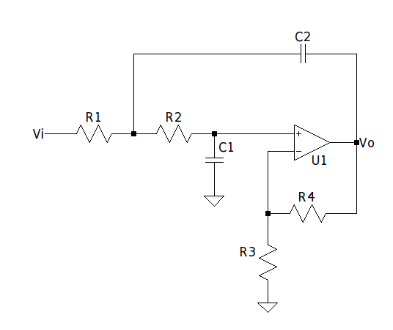

Planteamos las ecuaciones:
\begin{equation}
V_A(G_1+G_2+SC_2)-V_iG_1-V_oSC_2-V_BG2=0
\end{equation}
\begin{equation}
V_B(G_2+SC_1)-V_AG_2=0
\end{equation}
\begin{equation}
V_B(G_3+G_4)-V_oG_4=0
\end{equation}
Escribimos las matrices para poder resolver por metodo de cramer:

$$
\begin{bmatrix}
SC_2+G1+G2 & -G2 & -SC2\\
-G2 & SC_1+G2 & 0 \\
 0 & G_4+G_3 & -G4
\end{bmatrix}
\begin{bmatrix}
VA \\VB \\ VO
\end{bmatrix}
=
\begin{bmatrix}
V_iG_1\\0\\0
\end{bmatrix}
$$
Calculomos $V_o$:
$$
V_o=\frac{
\begin{vmatrix}
    SC_2+G1+G2 & -G2 & V_iG_1\\
    -G2 & SC_1+G2 & 0 \\
 0 & G_4+G_3 & 0
\end{vmatrix}
}
{
\begin{vmatrix}
SC_2+G1+G2 & -G2 & -SC2\\
-G2 & SC_1+G2 & 0 \\
 0 & G_4+G_3 & -G4
 \end{vmatrix}
}
= \frac{-V_iG_1G_2(G_4+G_3)}{-C_1C_2G_4S^2+S[G_2C_2(G_4+G_3)-G_4C_1(G_1+G_2)]+{G_2}^2G_4}
$$

La transferencia nos queda:

$$
\frac{V_o}{V_i} = \frac{(G_3+G_4)}{G_4}\frac{\frac{G_1G_2}{C_1C_2}}{S^2+S[\frac{(G_1+G_2)}{C_2}-\frac{G_2G_3}{G_4C_1}]+\frac{G_2G_1}{C_2C_1}} 
$$
Obligamos a que  $\frac{(G_3+G_4)}{G_4}=1$, entonces $G_3=0$
$$
\frac{V_o}{V_i} = \frac{\frac{G_1G_2}{C_1C_2}}{S^2+S[\frac{(G_1+G_2)}{C_2}]+\frac{G_2G_1}{C_2C_1}} 
$$

Donde:
$$
    {\omega_0}^2=\frac{G_1G_2}{C_1C_2}
$$
$$
    \frac{\omega_0}{Q_1}=\frac{(G_1+G_2)}{C_2}
$$
Para tener dos grados de libertad, tomamos $G_1=G_2=1$. Entonces:
$$
C_1C_2=1 
$$
$$
2Q_1=C_2
$$

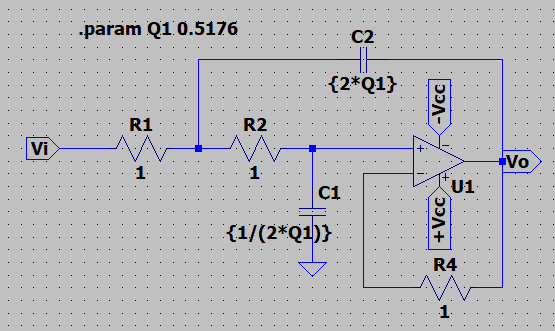

In [17]:
import sympy as sp
from IPython.display import display, Math

S,G1,G2,G3,G4,C1,C2=sp.symbols('S G1 G2 G3 G4 C1 C2')
VA,VB,Vi,Vo=sp.symbols('VA,VB,Vi,Vo')

eqs=[
    VA*(G1+G2+S*C2)-Vi*(G1)-Vo*S*C2-VB*G2,
    VB*(G2+S*C1)-VA*G2,
    VB*(G3+G4)-Vo*G4,
]

sol=sp.solve(eqs,[VA,VB,Vo])

T1 = sp.simplify(sol[Vo]/Vi)

display(Math("T1 = " + sp.latex(T1)))

<IPython.core.display.Math object>

#### Segundo SOS: KHN
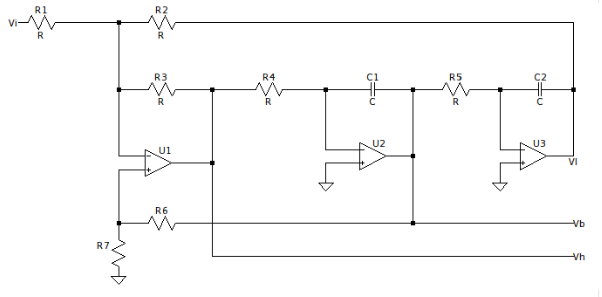

Planteamos las ecuaciones:
\begin{equation}
    V_A(G_1+G_2+G_3)-V_iG_1-V_oG_2-V_1G_3=0
\end{equation}
\begin{equation}
    V_A(G_6+G_7)-V_2G_6=0
\end{equation}
\begin{equation}
    V_oSC_2+V_2G_5=0
\end{equation}
\begin{equation}
    V_2SC_1+V_1G_4=0
\end{equation}

Resolviendo por sustitucion nos queda:
$$
T_2(S)=\frac{-G_1}{G_2}\frac{\frac{G_2G_4G_5}{C_1C_2G_3}}{S^2+S\frac{G_6G_4(G_1+G_2+G_3)}{G_3(G_6+G_7)}+\frac{G_2G_4G_5}{C_1C_2G_3}}
$$

Donde:
$$
    {\omega_0}^2=\frac{G_2G_4G_5}{C_1C_2G_3} 
$$
$$
    \frac{\omega_0}{Q_2}=\frac{G_6G_4(G_1+G_2+G_3)}{G_3(G_6+G_7)}
$$
Para tener dos grados de libertad, tomamos $G_1=G_2=G_4=G_5=G_6=G_7=C_1=1$. Entonces:
$$
G_3C_2=1 
$$
$$
Q_2=\frac{2 G_3}{2+G_3} \rightarrow G_3=\frac{2Q_2}{2-Q_2}
$$


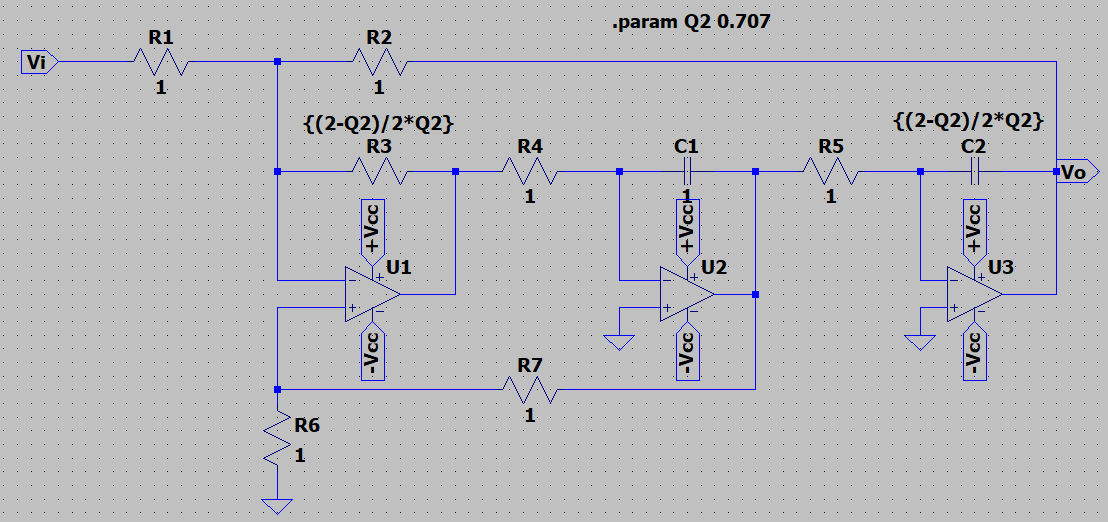


In [12]:
import sympy as sp
from IPython.display import display, Math

S,G1,G2,G3,G4,G5,G6,G7,C1,C2=sp.symbols('S G1 G2 G3 G4 G5 G6 G7 C1 C2')
VA,V2,V1,Vi,Vo=sp.symbols('VA,V2,V1,Vi,Vo')

eqs=[
    VA*(G1+G2+G3)-Vi*(G1)-Vo*G2-V1*G3,
    VA*(G6+G7)-V2*G6,
    Vo*S*C2+V2*G5,
    V2*S*C1+V1*G4
]

sol=sp.solve(eqs,[VA,V1,V2,Vo])

T2 = sp.simplify(sol[Vo]/Vi)

display(Math("T2 = " + sp.latex(T2)))

<IPython.core.display.Math object>

#### Tercer SOS:Multiple Feedback
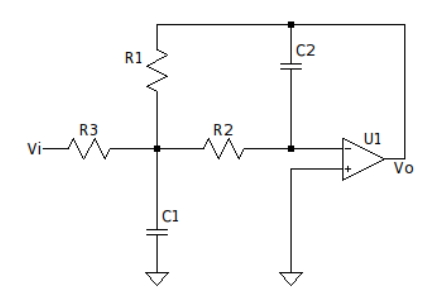

Planteamos las ecuaciones:
\begin{equation}
V_A(G_1+G_2+G_3+SC_1)-V_iG_3-V_oG_1=0
\end{equation}

\begin{equation}
V_oSC_2+V_AG_2=0
\end{equation}

Resolviendo nos queda:
$$
T_3(S)= \frac{-G_3}{G_1}\frac{\frac{G_1G_2}{C_1C_2}}{S^2+S\frac{(G_1+G_2+G_3)}{C_1}+\frac{G_1G_2}{C_1C_2}}
$$

Donde: 
$$
    {\omega_0}^2=\frac{G_1G_2}{C_1C_2} 
$$
$$
    \frac{\omega_0}{Q_3}=\frac{(G_1+G_2+G_3)}{C_1}
$$
Para tener dos grados de libertad, tomamos $G_1=G_2=G_3=1$. Entonces:
$$
C_1C_2=1 
$$
$$
Q_3=\frac{C_1}{3} \rightarrow C_1=3Q_3
$$

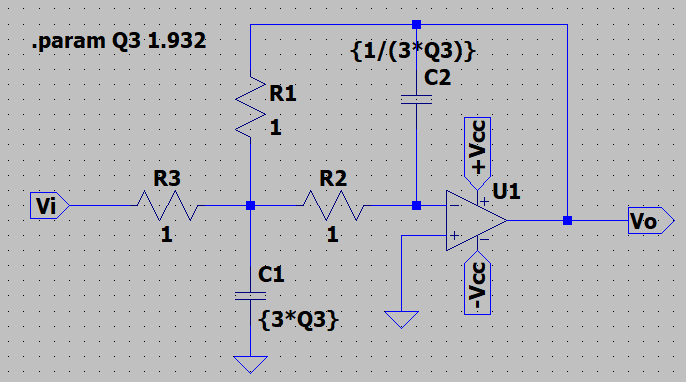


In [15]:
import sympy as sp
from IPython.display import display, Math

S,G1,G2,G3,C1,C2=sp.symbols('S G1 G2 G3 C1 C2')
VA,Vi,Vo=sp.symbols('VA,Vi,Vo')

eqs=[
    VA*(G1+G2+G3+S*C1)-Vi*G3-Vo*G1,
    Vo*S*C2+VA*G2
]

sol=sp.solve(eqs,[VA,Vo])

T3 = sp.simplify(sol[Vo]/Vi)

display(Math("T3 = " + sp.latex(T3)))

<IPython.core.display.Math object>

### Simulacion en LTSPICE
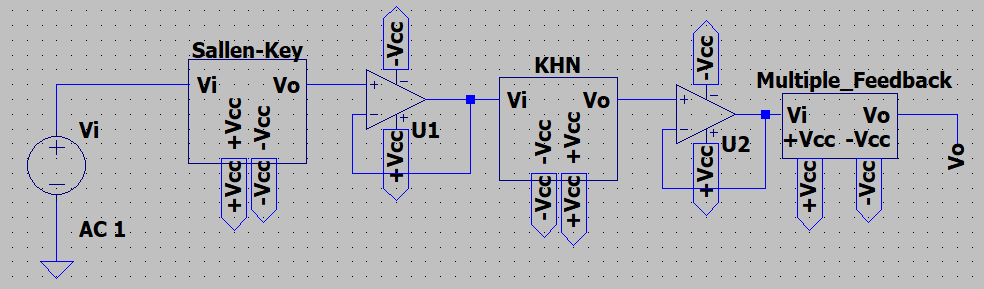

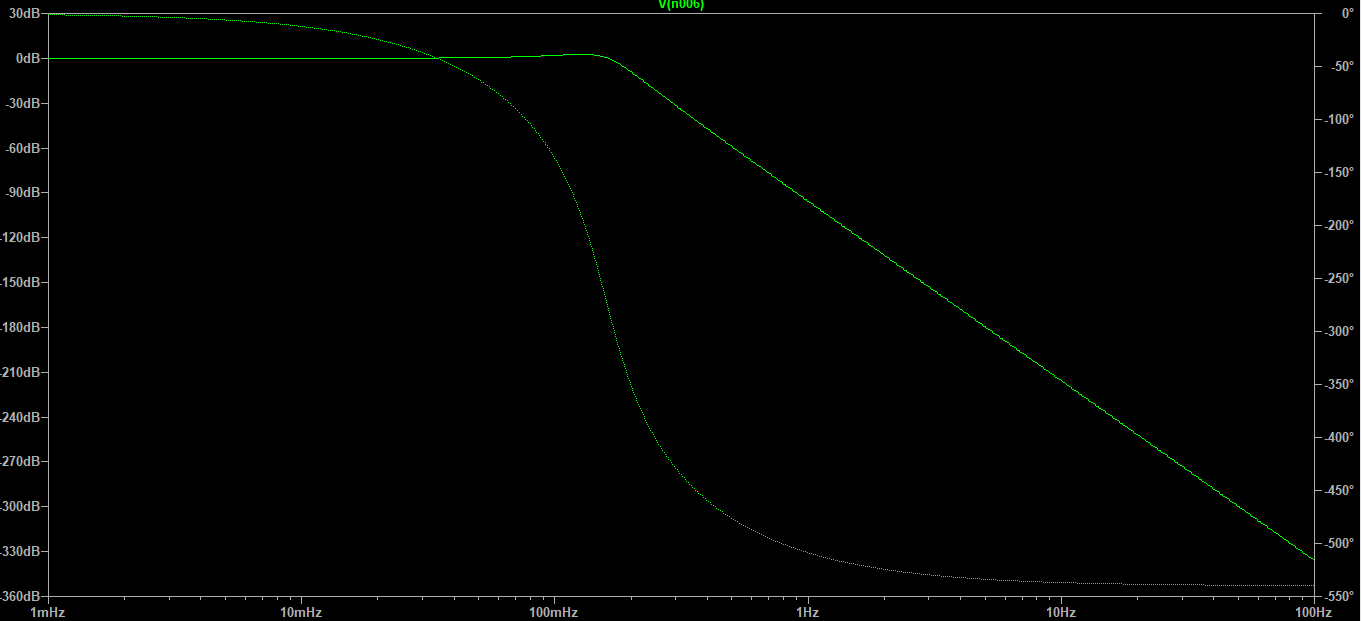